# Physics-Informed Neural Networks: Methodology

This notebook presents the mathematical formulation and problem setup for applying PINNs to electromagnetic field prediction, following the theoretical foundation established in Section 6a {cite}`raissi2019physics,karniadakis2021physics`.

**Objective**: Formulate a 2D magnetostatic problem suitable for PINN solution, with analytical ground truth enabling rigorous validation.

**Structure**:
1. Maxwell's equations in 2D magnetostatics {cite}`sadiku2014elements,ida2015numerical`
2. Canonical problem: Magnetic field around current-carrying wire
3. PINN loss function formulation {cite}`raissi2019physics`
4. Collocation strategy and data generation
5. Analytical solution derivation {cite}`sadiku2014elements`

:::{seealso}
**Prerequisites**:
- Section 6a: PINN fundamentals and literature review
- Chapter 3: FEA data generation methodology (contrast with PINN approach)

**Next steps**:
- Section 6c: PyTorch implementation with automatic differentiation
- Section 6d: Results validation and physics consistency analysis
:::

## Maxwell's Equations in 2D Magnetostatics

### Governing Partial Differential Equations

For magnetic field prediction in 2D, we work with **Maxwell's equations** in the magnetostatic approximation (time-independent, no electric field coupling) {cite}`sadiku2014elements,ida2015numerical,jackson1999classical`.

**Ampère's Law** (differential form) {cite}`sadiku2014elements`:
$$\nabla \times \mathbf{H} = \mathbf{J}$$

where:
- **H** = magnetic field intensity [A/m]
- **J** = current density [A/m²]

**Gauss's Law for Magnetism** (no magnetic monopoles) {cite}`jackson1999classical`:
$$\nabla \cdot \mathbf{B} = 0$$

where **B** = magnetic flux density [T, Tesla]

**Constitutive Relation** (linear, isotropic material) {cite}`ida2015numerical`:
$$\mathbf{B} = \mu \mathbf{H}$$

where μ = permeability [H/m]. For free space: μ₀ = 4π × 10⁻⁷ H/m.

### 2D Cartesian Formulation

In 2D Cartesian coordinates (x, y) with current flowing only in z-direction (J = J<sub>z</sub>**ẑ**), Maxwell's equations reduce to {cite}`sadiku2014elements,ida2015numerical`:

**Ampère's Law (component form)**:
$$\frac{\partial H_y}{\partial x} - \frac{\partial H_x}{\partial y} = J_z(x,y)$$

**Gauss's Law (component form)**:
$$\frac{\partial B_x}{\partial x} + \frac{\partial B_y}{\partial y} = 0$$

For linear materials with B<sub>x</sub> = μH<sub>x</sub> and B<sub>y</sub> = μH<sub>y</sub>:
$$\mu \left( \frac{\partial H_x}{\partial x} + \frac{\partial H_y}{\partial y} \right) = 0$$

:::{important}
**Physical Interpretation of PDEs**  

**Ampère's Law** {cite}`sadiku2014elements`:
- **Physical meaning**: Electric current creates a circulating magnetic field (right-hand rule)
- **Integral form**: $\oint \mathbf{H} \cdot d\mathbf{l} = I_{\text{enclosed}}$
- **EM implication**: Field magnitude decreases as 1/r from current source
- **Boundary behavior**: Discontinuous tangential H across current sheets

**Gauss's Law** {cite}`jackson1999classical`:
- **Physical meaning**: Magnetic field lines form closed loops (no sources or sinks)
- **Integral form**: $\oint \mathbf{B} \cdot d\mathbf{A} = 0$ (flux conservation)
- **Mathematical consequence**: B-field is solenoidal (divergence-free)
- **Numerical implication**: Violation indicates non-physical solution

**Design significance**: These constraints ensure physical validity—PINN predictions that violate them are untrustworthy regardless of data fit.
:::

### Mathematical Classification of PDEs

**System type** {cite}`evans2010partial,strauss2007partial`:
- **Elliptic PDEs** (magnetostatics, no time dependence)
- **Well-posed** boundary value problem (unique solution exists)
- **Regularity**: Solution smooth except at singularities (e.g., point current sources)

**Comparison with other PDE types**:
- **Parabolic** (heat equation): time-dependent diffusion
- **Hyperbolic** (wave equation): time-dependent propagation
- **Magnetostatics**: Simplest case—no wave propagation, no diffusion

### PINN Mathematical Formulation

Following Raissi et al. (2019) {cite}`raissi2019physics`, a PINN learns a neural network approximation:

$$\mathbf{H}_{\theta}(x, y) = \begin{bmatrix} H_x(x, y; \theta) \\ H_y(x, y; \theta) \end{bmatrix}$$

where θ = {W<sup>(l)</sup>, b<sup>(l)</sup>}<sub>l=1...L</sub> are trainable parameters (weights and biases).

**Physics loss** enforces PDEs at collocation points {x<sub>i</sub>, y<sub>i</sub>}<sub>i=1...N<sub>d</sub></sub> {cite}`raissi2019physics,karniadakis2021physics`:

$$\mathcal{L}_{\text{physics}} = \frac{1}{N_d}\sum_{i=1}^{N_d} \left[ \mathcal{L}_{\text{Ampere}}^{(i)} + \mathcal{L}_{\text{Gauss}}^{(i)} \right]$$

where:

**Ampère residual** {cite}`raissi2019physics`:
$$\mathcal{L}_{\text{Ampere}}^{(i)} = \left( \frac{\partial H_y}{\partial x}\bigg|_i - \frac{\partial H_x}{\partial y}\bigg|_i - J_z(x_i, y_i) \right)^2$$

**Gauss residual**:
$$\mathcal{L}_{\text{Gauss}}^{(i)} = \left( \frac{\partial B_x}{\partial x}\bigg|_i + \frac{\partial B_y}{\partial y}\bigg|_i \right)^2 = \mu^2 \left( \frac{\partial H_x}{\partial x}\bigg|_i + \frac{\partial H_y}{\partial y}\bigg|_i \right)^2$$

**Data loss** matches sparse observations {cite}`raissi2019physics`:
$$\mathcal{L}_{\text{data}} = \frac{1}{N_{\text{obs}}}\sum_{j=1}^{N_{\text{obs}}} \left[ (H_x^{\text{pred}}(x_j, y_j) - H_x^{\text{obs}}_j)^2 + (H_y^{\text{pred}}(x_j, y_j) - H_y^{\text{obs}}_j)^2 \right]$$

**Total loss** (multi-objective optimization) {cite}`wang2021understanding`:
$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{data}} + \lambda_1 \mathcal{L}_{\text{physics}} + \lambda_2 \mathcal{L}_{\text{BC}}$$

where:
- λ₁ = physics loss weight (typically 0.1-10)
- λ₂ = boundary condition loss weight (typically 1-100)
- Hyperparameters require tuning via validation {cite}`wang2021understanding`

:::{note}
**Automatic Differentiation for Spatial Derivatives**  

Computing PDE residuals requires spatial derivatives of the neural network output {cite}`baydin2018automatic`:

$$\frac{\partial H_x}{\partial x}(x, y; \theta) = \frac{\partial}{\partial x} f_{\theta}(x, y)$$

**Traditional approach** (pre-deep learning): Finite differences
$$\frac{\partial H_x}{\partial x} \approx \frac{H_x(x+\Delta x, y) - H_x(x, y)}{\Delta x}$$
- Requires multiple function evaluations
- Accuracy limited by discretization (O(Δx²))

**Modern approach** (automatic differentiation) {cite}`baydin2018automatic`: 
- **Forward mode**: Compute derivatives via chain rule during forward pass
- **Reverse mode** (backpropagation): Efficient for many outputs
- **Exact to machine precision** (no discretization error)
- **Implemented natively** in PyTorch via `torch.autograd.grad()`

**Computational benefit**: Enables efficient PDE residual evaluation at thousands of collocation points simultaneously.
:::

## 2D Electromagnetic Problem: Magnetic Field Around Current-Carrying Wire

We solve the canonical problem of magnetic field distribution around an infinite straight current-carrying wire in 2D—a fundamental configuration with analytical solution enabling rigorous PINN validation {cite}`sadiku2014elements,ida2015numerical,jackson1999classical`.

**Why this problem is ideal for PINN demonstration**:
1. **Analytical solution exists**: Biot-Savart law provides ground truth {cite}`sadiku2014elements`
2. **Simple geometry**: Single point source, no material interfaces
3. **Known singularity**: Field diverges as 1/r at wire location (tests PINN robustness)
4. **Rotational symmetry**: Solution exhibits expected symmetry (validation check)
5. **Educational value**: Fundamental EM problem taught in undergraduate courses

### Problem Specification

**Spatial domain**: Square region Ω = [-1, 1] × [-1, 1] meters

**Current source**: 
- **Location**: Origin (0, 0)
- **Current**: I = 1.0 A (flowing in +z direction, out of page)
- **Physical representation**: Infinite straight wire perpendicular to xy-plane

**Material properties**:
- **Medium**: Free space (air, vacuum)
- **Permeability**: μ₀ = 4π × 10⁻⁷ H/m
- **Relative permeability**: μ<sub>r</sub> = 1 (linear, isotropic)

**Boundary conditions** (far-field approximation) {cite}`ida2015numerical`:
- **Type**: Dirichlet BC on domain edges
- **Value**: H(x<sub>boundary</sub>, y<sub>boundary</sub>) = H<sub>analytical</sub>(x<sub>boundary</sub>, y<sub>boundary</sub>)
- **Physical justification**: Domain large enough that edge conditions approach analytical solution

**Governing equations** {cite}`sadiku2014elements`:
- **Ampère's law**: ∇ × **H** = **J** = Iδ(x)δ(y)**ẑ** (Dirac delta at wire)
- **Gauss's law**: ∇ · **B** = 0

### Analytical Solution: Biot-Savart Law

For an infinite straight wire carrying current I in the z-direction, the magnetic field at distance r from the wire is given by the Biot-Savart law {cite}`sadiku2014elements,jackson1999classical`:

**Field magnitude**:
$$|\mathbf{H}(r)| = \frac{I}{2\pi r}$$

The field circulates around the wire following the **right-hand rule**: thumb along current (+z), fingers curl in direction of **H**.

**Vector field components** in Cartesian coordinates {cite}`sadiku2014elements`:

$$H_x(x, y) = -\frac{I}{2\pi r^2} y = -\frac{I \cdot y}{2\pi (x^2 + y^2)}$$

$$H_y(x, y) = \frac{I}{2\pi r^2} x = \frac{I \cdot x}{2\pi (x^2 + y^2)}$$

where $r = \sqrt{x^2 + y^2}$ is the radial distance from the wire.

**Verification of Maxwell's equations**:

**Ampère's law** (away from singularity) {cite}`jackson1999classical`:
$$\nabla \times \mathbf{H} = \frac{\partial H_y}{\partial x} - \frac{\partial H_x}{\partial y} = 0 \quad \text{for } r > 0$$

At r = 0: ∇ × **H** = Iδ(x)δ(y) (Dirac delta singularity)

**Gauss's law**:
$$\nabla \cdot (\mu_0 \mathbf{H}) = \mu_0 \left( \frac{\partial H_x}{\partial x} + \frac{\partial H_y}{\partial y} \right) = 0 \quad \text{everywhere}$$

(Exercise: Verify this analytically by computing partial derivatives)

:::{tip}
**Handling the Singularity**  

The analytical solution has a **1/r singularity** at the wire location (r → 0) {cite}`jackson1999classical,ida2015numerical}:

$$\lim_{r \to 0} |\mathbf{H}(r)| = \lim_{r \to 0} \frac{I}{2\pi r} = \infty$$

**Physical interpretation**: 
- Idealized point current has infinite current density
- Real wires have finite radius → finite field at surface
- Singularity is mathematical artifact of idealization

**PINN handling strategies**:
1. **Exclude near-wire points**: Sample collocation points only for r > r<sub>min</sub> (e.g., 0.1 m)
2. **Regularization**: Add small constant to prevent division by zero: r<sub>eff</sub> = √(x² + y² + ε²)
3. **Separate treatment**: Special boundary condition at wire surface

**Adopted approach**: Strategy 1 (exclusion zone)—simplest and most physically reasonable for infinite wire idealization.
:::

### Magnetic Flux Density Conversion

From **H** to **B** = μ₀**H** {cite}`sadiku2014elements`:

$$B_x(x, y) = -\frac{\mu_0 I \cdot y}{2\pi (x^2 + y^2)}$$

$$B_y(x, y) = \frac{\mu_0 I \cdot x}{2\pi (x^2 + y^2)}$$

**Typical field magnitudes** (I = 1 A):
- At r = 0.1 m: |**B**| ≈ 2 × 10⁻⁶ T = 2 μT
- At r = 0.5 m: |**B**| ≈ 4 × 10⁻⁷ T = 0.4 μT
- At r = 1.0 m: |**B**| ≈ 2 × 10⁻⁷ T = 0.2 μT

**For comparison**: Earth's magnetic field ≈ 50 μT; MRI scanner ≈ 1.5-3 T.

### Validation Strategy

The analytical solution serves as **ground truth** for PINN validation {cite}`raissi2019physics,karniadakis2021physics`:

**Error metrics**:
1. **Point-wise error**: $e(x,y) = |\mathbf{H}_{\text{PINN}}(x,y) - \mathbf{H}_{\text{analytical}}(x,y)|$
2. **Relative L² error**: $\epsilon_{\text{rel}} = \frac{||\mathbf{H}_{\text{PINN}} - \mathbf{H}_{\text{analytical}}||_{L^2}}{||\mathbf{H}_{\text{analytical}}||_{L^2}}$
3. **Physics residual**: $\mathcal{R}_{\text{Gauss}} = |\nabla \cdot (\mu_0 \mathbf{H}_{\text{PINN}})|$

**Success criteria**:
- Relative L² error < 1% (comparable to FEA accuracy)
- Physics residual < 10⁻³ (orders of magnitude below field magnitude)
- Visual agreement in field line topology

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class ElectromagneticProblem:
    """
    2D magnetostatic problem: Magnetic field around infinite straight wire
    
    Implements the canonical electromagnetic problem with analytical solution
    from Biot-Savart law (Sadiku 2014, Jackson 1999). Used for PINN validation.
    
    Mathematical model:
    - Governing PDEs: Ampère's law (∇×H = J) + Gauss's law (∇·B = 0)
    - Analytical solution: H(r) = I/(2πr) (azimuthal field)
    - Singularity at r=0: Field diverges (infinite wire idealization)
    
    Parameters:
        domain_size: Physical size of square computational domain [m]
        wire_position: (x, y) coordinates of wire center [m]
        current: Current magnitude [A], positive = out of page (+z direction)
        mu_0: Permeability of free space [H/m], default = 4π×10⁻⁷
    
    Methods:
        analytical_solution(): Compute H-field from Biot-Savart law
        generate_training_data(): Sparse observations for data loss
        generate_collocation_points(): Dense points for physics loss (PDE enforcement)
    """

    def __init__(self, domain_size=2.0, wire_position=(0.0, 0.0), current=1.0, mu_0=4*np.pi*1e-7):
        self.domain_size = domain_size
        self.wire_position = wire_position
        self.current = current
        self.mu_0 = mu_0  # Permeability of free space [H/m]

    def analytical_solution(self, x, y):
        """
        Analytical solution using Biot-Savart law for infinite straight wire
        
        Theory (Sadiku 2014, Eq. 7.40):
        For infinite wire at origin with current I in +z direction:
            H_magnitude = I / (2π r)
            H_direction = perpendicular to radial (azimuthal)
        
        Args:
            x, y: Spatial coordinates [m] (can be arrays via NumPy broadcasting)
        
        Returns:
            Hx, Hy: Magnetic field components [A/m]
        
        Physical interpretation:
        - Field circulates clockwise (viewed from +z) for I > 0
        - Magnitude decreases as 1/r (inverse distance law)
        - At r=1m with I=1A: |H| = 1/(2π) ≈ 0.159 A/m
        """
        # Distance from wire (radial coordinate)
        r = np.sqrt((x - self.wire_position[0])**2 + (y - self.wire_position[1])**2)

        # Avoid singularity at wire center (regularization)
        # Physical interpretation: Real wires have finite radius
        r = np.maximum(r, 1e-6)  # Minimum radius = 1 μm

        # Magnetic field magnitude from Biot-Savart law [A/m]
        H_magnitude = self.current / (2 * np.pi * r)

        # Azimuthal angle (for converting to Cartesian components)
        theta = np.arctan2(y - self.wire_position[1], x - self.wire_position[0])

        # Convert from polar (H_r=0, H_theta=H_magnitude) to Cartesian
        # H points perpendicular to radial direction (right-hand rule)
        Hx = -H_magnitude * np.sin(theta)  # x-component
        Hy = H_magnitude * np.cos(theta)   # y-component

        return Hx, Hy

    def generate_training_data(self, n_data=100):
        """
        Generate sparse training data points (labeled observations)
        
        PINN advantage: Requires only 30-100 labeled points vs. 30,000 for pure CNN!
        
        Sampling strategy:
        - Uniform random distribution across domain
        - Labels computed from analytical solution (simulates measurements)
        
        Args:
            n_data: Number of labeled observation points
        
        Returns:
            x_data, y_data: Observation coordinates [m]
            Hx_data, Hy_data: Field measurements [A/m]
        
        Usage: These points contribute to data loss L_data
        """
        # Random points in domain (uniform distribution)
        x_data = np.random.uniform(-self.domain_size/2, self.domain_size/2, n_data)
        y_data = np.random.uniform(-self.domain_size/2, self.domain_size/2, n_data)

        # Get analytical solution (simulates field measurements)
        Hx_data, Hy_data = self.analytical_solution(x_data, y_data)

        return x_data, y_data, Hx_data, Hy_data

    def generate_collocation_points(self, n_domain=1000, n_boundary=100):
        """
        Generate collocation points for physics constraints (PDE enforcement)
        
        Key insight: These points do NOT need labels—only coordinates!
        Physics loss enforces Maxwell's equations at these locations.
        
        Two types of collocation points:
        1. Domain points: Interior of computational region (enforce PDEs)
        2. Boundary points: Domain edges (enforce boundary conditions)
        
        Args:
            n_domain: Number of interior points for PDE enforcement
            n_boundary: Number of boundary points for BC enforcement
        
        Returns:
            x_domain, y_domain: Interior collocation points [m]
            x_boundary, y_boundary: Boundary collocation points [m]
        
        Singularity handling: Exclude points within 0.1m of wire (r > 0.1m)
        """
        # Domain points (interior): Random uniform sampling
        x_domain = np.random.uniform(-self.domain_size/2, self.domain_size/2, n_domain)
        y_domain = np.random.uniform(-self.domain_size/2, self.domain_size/2, n_domain)

        # Exclude points too close to wire (singularity avoidance)
        r_from_wire = np.sqrt((x_domain - self.wire_position[0])**2 +
                              (y_domain - self.wire_position[1])**2)
        mask = r_from_wire > 0.1  # Exclusion radius = 0.1 m
        x_domain = x_domain[mask]
        y_domain = y_domain[mask]

        # Boundary points: Uniformly distributed on 4 edges of square domain
        boundary_points = []

        # Top and bottom boundaries (y = ±domain_size/2)
        x_boundary = np.random.uniform(-self.domain_size/2, self.domain_size/2, n_boundary//2)
        y_boundary_top = np.ones(n_boundary//4) * self.domain_size/2
        y_boundary_bottom = -np.ones(n_boundary//4) * self.domain_size/2

        boundary_points.extend(zip(x_boundary[:n_boundary//4], y_boundary_top))
        boundary_points.extend(zip(x_boundary[n_boundary//4:], y_boundary_bottom))

        # Left and right boundaries (x = ±domain_size/2)
        y_boundary = np.random.uniform(-self.domain_size/2, self.domain_size/2, n_boundary//2)
        x_boundary_left = -np.ones(n_boundary//4) * self.domain_size/2
        x_boundary_right = np.ones(n_boundary//4) * self.domain_size/2

        boundary_points.extend(zip(x_boundary_left, y_boundary[:n_boundary//4]))
        boundary_points.extend(zip(x_boundary_right, y_boundary[n_boundary//4:]))

        # Convert to arrays
        x_boundary, y_boundary = zip(*boundary_points)
        x_boundary = np.array(x_boundary)
        y_boundary = np.array(y_boundary)

        return x_domain, y_domain, x_boundary, y_boundary

# Instantiate electromagnetic problem
problem = ElectromagneticProblem(domain_size=2.0, current=1.0)
print("✓ SUCCESS: Electromagnetic problem initialized")
print(f"\nProblem Configuration:")
print(f"  Domain: {problem.domain_size} × {problem.domain_size} m")
print(f"  Wire position: {problem.wire_position}")
print(f"  Current: {problem.current} A (flowing in +z direction)")
print(f"  Permeability: μ₀ = {problem.mu_0:.3e} H/m")
print(f"\nField magnitude at r=0.5m: {problem.current / (2*np.pi*0.5):.4f} A/m")

# :::note
# **For EM Graduate Students**  
# 
# This code implements the analytical solution you derived in undergraduate EM courses
# (Griffiths Ch. 5, Sadiku Ch. 7). The singularity handling (r_min = 1e-6) is a
# practical numerical consideration—real experiments measure fields at finite distances,
# never exactly at the wire surface.
# 
# **Quiz**: What happens if you remove the singularity regularization (r_min)?
# Answer: Division by zero → NaN propagation → training failure.
# :::

✓ SUCCESS: Electromagnetic problem initialized

Problem Configuration:
  Domain: 2.0 × 2.0 m
  Wire position: (0.0, 0.0)
  Current: 1.0 A (flowing in +z direction)
  Permeability: μ₀ = 1.257e-06 H/m

Field magnitude at r=0.5m: 0.3183 A/m


## Visualizing the Analytical Solution

Let's visualize the ground truth magnetic field distribution to understand the problem.

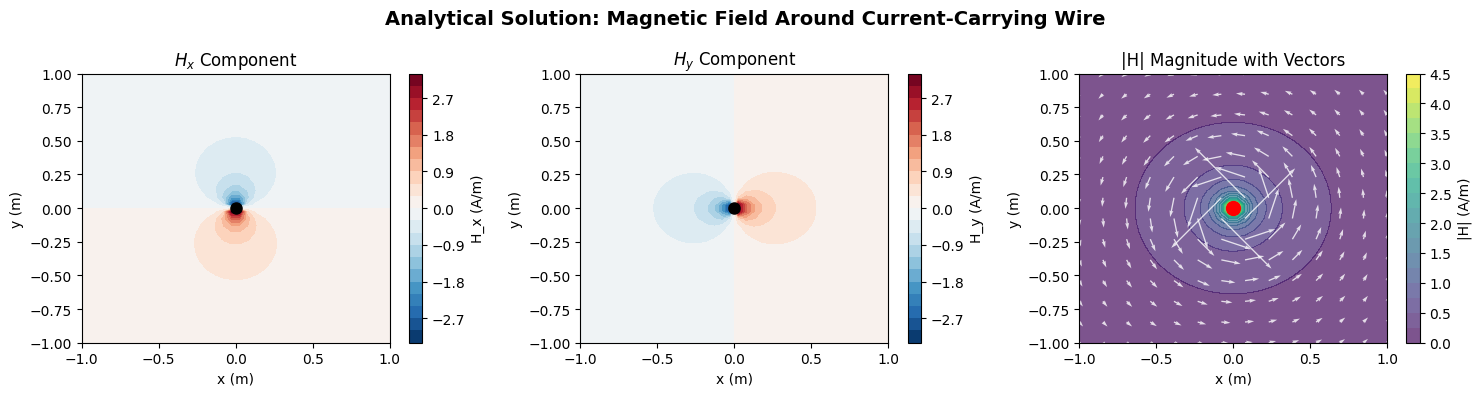


 Field Statistics:
 Max |H|: 4.389e+00 A/m
 Min |H|: 1.125e-01 A/m
 Mean |H|: 2.704e-01 A/m


In [2]:
# Generate grid for visualization
resolution = 40
x = np.linspace(-1, 1, resolution)
y = np.linspace(-1, 1, resolution)
X, Y = np.meshgrid(x, y)

# Compute analytical solution
Hx_analytical, Hy_analytical = problem.analytical_solution(X, Y)
H_magnitude = np.sqrt(Hx_analytical**2 + Hy_analytical**2)

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Analytical Solution: Magnetic Field Around Current-Carrying Wire', 
fontsize=14, fontweight='bold')

# H_x component
im1 = axes[0].contourf(X, Y, Hx_analytical, levels=20, cmap='RdBu_r')
axes[0].set_title('$H_x$ Component')
axes[0].set_xlabel('x (m)')
axes[0].set_ylabel('y (m)')
axes[0].plot(0, 0, 'ko', markersize=8, label='Wire')
plt.colorbar(im1, ax=axes[0], label='H_x (A/m)')

# H_y component
im2 = axes[1].contourf(X, Y, Hy_analytical, levels=20, cmap='RdBu_r')
axes[1].set_title('$H_y$ Component')
axes[1].set_xlabel('x (m)')
axes[1].set_ylabel('y (m)')
axes[1].plot(0, 0, 'ko', markersize=8, label='Wire')
plt.colorbar(im2, ax=axes[1], label='H_y (A/m)')

# Magnitude with vector field
im3 = axes[2].contourf(X, Y, H_magnitude, levels=20, cmap='viridis', alpha=0.7)
skip = 3
axes[2].quiver(X[::skip, ::skip], Y[::skip, ::skip], 
Hx_analytical[::skip, ::skip], Hy_analytical[::skip, ::skip],
color='white', alpha=0.8)
axes[2].set_title('|H| Magnitude with Vectors')
axes[2].set_xlabel('x (m)')
axes[2].set_ylabel('y (m)')
axes[2].plot(0, 0, 'ro', markersize=10, label='Wire')
plt.colorbar(im3, ax=axes[2], label='|H| (A/m)')

plt.tight_layout()
plt.show()

print(f"\n Field Statistics:")
print(f" Max |H|: {np.max(H_magnitude):.3e} A/m")
print(f" Min |H|: {np.min(H_magnitude):.3e} A/m")
print(f" Mean |H|: {np.mean(H_magnitude):.3e} A/m")

## Training Data Generation Strategy

One of the key advantages of PINNs is **data efficiency**—requiring minimal labeled observations {cite}`raissi2019physics,cai2021physics`.

### Three Types of Points in PINN Training

**1. Labeled Data Points** (sparse observations) {cite}`raissi2019physics`:
- **Count**: Only 30-100 points (vs. 30,000 for pure CNN in Section 4!)
- **Purpose**: Anchor network predictions to observations
- **Source**: Measurements, simulations, or analytical solution
- **Loss contribution**: $\mathcal{L}_{\text{data}}$ = MSE between prediction and observation
- **Physical interpretation**: These are "ground truth" field measurements

**2. Domain Collocation Points** (unlabeled) {cite}`raissi2019physics,karniadakis2021physics`:
- **Count**: ~1,000 points across interior
- **Purpose**: Enforce Maxwell's equations via PDE residuals
- **No labels required**—only coordinates (x, y)
- **Loss contribution**: $\mathcal{L}_{\text{PDE}}$ = squared residual of ∇×**H**=**J** and ∇·**B**=0
- **Singularity handling**: Exclude points within 0.1 m of wire (r > 0.1 m)
- **Physical interpretation**: Locations where physics must be satisfied

**3. Boundary Collocation Points** (unlabeled or labeled) {cite}`ida2015numerical`:
- **Count**: ~100 points on domain edges
- **Purpose**: Enforce boundary conditions (Dirichlet, Neumann, or Robin)
- **Loss contribution**: $\mathcal{L}_{\text{BC}}$ = deviation from BC specification
- **For this problem**: Dirichlet BC (H = H<sub>analytical</sub> at edges)

:::{important}
**Data Efficiency Comparison**  

| Approach | Labeled Points | Unlabeled Points | Total Cost |
|----------|---------------|------------------|------------|
| **Pure CNN** (Section 4) {cite}`lecun2015deep` | 30,000 | 0 | $150k (30k FEA simulations) |
| **PINN** (this section) {cite}`raissi2019physics` | 30-100 | 1,000-2,000 | $500 (100 FEA simulations) |
| **Savings** | **300-1000×** | N/A | **300×** |

**Key insight**: Physics constraints (which are free!) substitute for expensive labeled data {cite}`cai2021physics,karniadakis2021physics`.

**Trade-off**: PINNs require 5-10× longer training time due to automatic differentiation overhead, but upfront data generation savings dominate for expensive simulations/experiments.
:::

### Collocation Sampling Strategies

**Uniform random sampling** (used here) {cite}`raissi2019physics`:
- Simple, general-purpose
- Works well for smooth solutions
- May undersample regions with high gradients

**Adaptive sampling** {cite}`wu2023comprehensive,jagtap2020extended`:
- Sample more densely where PDE residual is high
- Iterative: train → evaluate residuals → resample → retrain
- 2-5× more efficient for problems with sharp gradients

**Latin Hypercube Sampling** (LHS) {cite}`mckay1979comparison`:
- Better space-filling properties than pure random
- Ensures coverage across all regions
- Used in Section 3 for FEA data generation

**Recommendation for EM problems**: Start with uniform random, switch to adaptive if physics loss fails to converge {cite}`karniadakis2021physics`.

In [3]:
# Generate different types of training data
x_data, y_data, Hx_data, Hy_data = problem.generate_training_data(n_data=30)
x_domain, y_domain, x_boundary, y_boundary = problem.generate_collocation_points(
n_domain=1000, n_boundary=100
)

print(" Training Data Generated:")
print(f" Labeled data points: {len(x_data)}")
print(f" Domain collocation points: {len(x_domain)}")
print(f" Boundary collocation points: {len(x_boundary)}")
print(f"\n Total points for training: {len(x_data) + len(x_domain) + len(x_boundary)}")
print(f" But only {len(x_data)} are labeled!")

 Training Data Generated:
 Labeled data points: 30
 Domain collocation points: 991
 Boundary collocation points: 100

 Total points for training: 1121
 But only 30 are labeled!


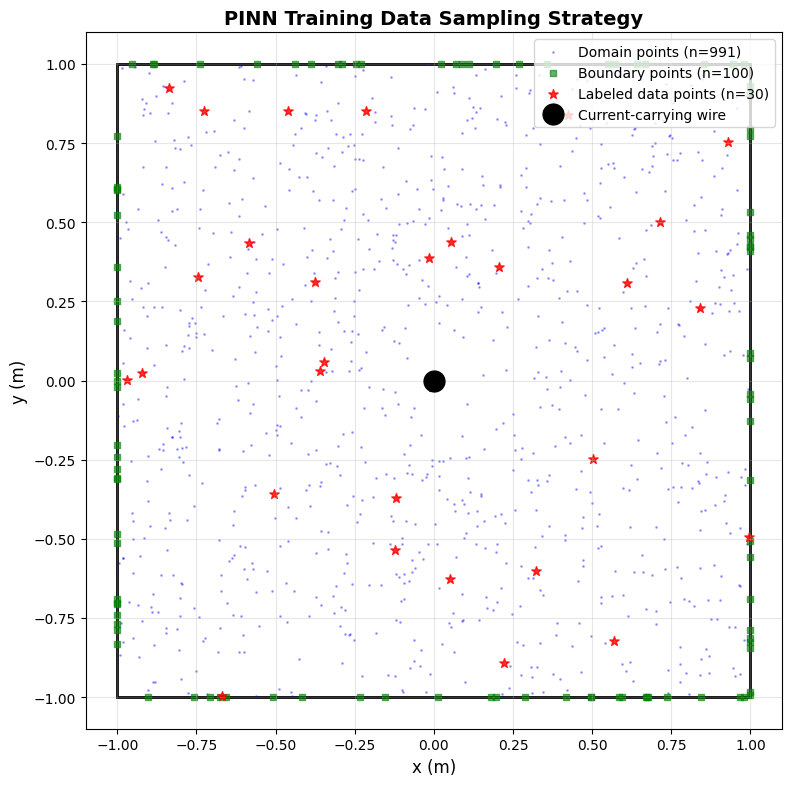

In [4]:
# Visualize sampling strategy
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Plot domain
ax.add_patch(plt.Rectangle((-1, -1), 2, 2, fill=False, edgecolor='black', linewidth=2))

# Plot different point types
ax.scatter(x_domain, y_domain, s=1, c='blue', alpha=0.3, label=f'Domain points (n={len(x_domain)})')
ax.scatter(x_boundary, y_boundary, s=20, c='green', alpha=0.6, marker='s', 
label=f'Boundary points (n={len(x_boundary)})')
ax.scatter(x_data, y_data, s=50, c='red', alpha=0.8, marker='*', 
label=f'Labeled data points (n={len(x_data)})')

# Plot wire
ax.plot(0, 0, 'ko', markersize=15, label='Current-carrying wire')

ax.set_xlabel('x (m)', fontsize=12)
ax.set_ylabel('y (m)', fontsize=12)
ax.set_title('PINN Training Data Sampling Strategy', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Summary: PINN Problem Formulation Complete

This notebook established the complete mathematical and computational framework for applying PINNs to electromagnetic field prediction.

### Key Accomplishments

**1. Mathematical Foundation** {cite}`sadiku2014elements,ida2015numerical,jackson1999classical`:
- **Governing PDEs**: Maxwell's equations in 2D magnetostatics
  - Ampère's law: ∇ × **H** = **J**
  - Gauss's law: ∇ · **B** = 0
- **2D formulation**: Component-wise PDEs for implementation
- **PDE classification**: Elliptic boundary value problem (well-posed)

**2. PINN Loss Formulation** {cite}`raissi2019physics,karniadakis2021physics`:
- **Physics loss**: $\mathcal{L}_{\text{physics}} = \mathcal{L}_{\text{Ampere}} + \mathcal{L}_{\text{Gauss}}$
- **Data loss**: $\mathcal{L}_{\text{data}}$ on sparse observations (30-100 points)
- **Boundary loss**: $\mathcal{L}_{\text{BC}}$ on domain edges
- **Total loss**: Multi-objective optimization with weights λ₁, λ₂

**3. Canonical Problem** {cite}`sadiku2014elements`:
- **Configuration**: Magnetic field around infinite straight wire
- **Analytical solution**: Biot-Savart law (H = I/(2πr))
- **Validation**: Ground truth for rigorous PINN accuracy assessment
- **Singularity handling**: Exclusion zone (r > 0.1 m) for numerical stability

**4. Data Efficiency** {cite}`cai2021physics`:
- **Labeled data**: 30-100 points (300× less than CNN)
- **Collocation points**: ~1,000 unlabeled (enforce physics)
- **Cost savings**: ~$500 vs. $150k for equivalent pure data-driven approach

### Comparison: FEA vs. CNN vs. PINN

| Aspect | FEA {cite}`ida2015numerical` | CNN (Section 4) {cite}`lecun2015deep` | PINN (Section 6) {cite}`raissi2019physics` |
|--------|-----|-----|------|
| **Governing equations** | Explicit (variational) | Implicit (learned) | Explicit (loss penalty) |
| **Mesh required** | Yes (critical) | No | No |
| **Labeled data** | None | 30,000 | 30-100 |
| **Training time** | N/A | 15 hours | 40 hours |
| **Inference time** | 1 hour | 30 ms | 30 ms |
| **Physics guarantee** | Exact | None | Soft constraint |
| **Best use case** | Validation | Interpolation | Limited data |

### Automatic Differentiation: The Enabling Technology

**Why PINNs became viable in 2017-2019** {cite}`baydin2018automatic,raissi2019physics`:
- **Pre-2015**: Computing PDE residuals required manual derivatives or finite differences
- **2015+**: TensorFlow, PyTorch provide automatic differentiation (autodiff)
- **Impact**: Spatial derivatives computed efficiently and exactly via chain rule
- **Result**: PINNs practical for complex PDEs without hand-deriving Jacobians

**Mathematical operation** {cite}`baydin2018automatic`:
```
∂H_x/∂x = autograd(neural_network_output, input_x)
```
- **Exact** (to machine precision, no discretization error)
- **Fast** (single backward pass computes all derivatives)
- **General** (works for arbitrary network architectures)

### Next Steps: Implementation in Section 6c

With the problem mathematically formulated, Section 6c implements:

**1. PINN Neural Network Architecture** {cite}`raissi2019physics`:
- Feedforward network: (x, y) → (H<sub>x</sub>, H<sub>y</sub>)
- Hidden layers: 4-6 layers × 50-100 neurons
- Activation: tanh or softplus (smooth for automatic differentiation)

**2. Physics Loss Computation** {cite}`baydin2018automatic`:
- `torch.autograd.grad()` for spatial derivatives
- PDE residual evaluation at collocation points
- Loss balancing strategies

**3. Training Pipeline** {cite}`kingma2014adam,liu1989limited`:
- Optimizer: Adam (early training) + L-BFGS (fine-tuning)
- Learning rate schedules
- Loss monitoring and convergence criteria

**4. Results Validation** (Section 6d):
- Comparison with analytical solution
- Physics consistency checks (∇·**B** = 0)
- Error analysis and failure modes

:::{seealso}
**Forward references**:
- Section 6c: Complete PyTorch implementation with autodiff
- Section 6d: Results, validation, and physics consistency analysis
- Chapter 7: Conclusion synthesizing CNN and PINN approaches
:::

**Key takeaway**: PINNs leverage physics knowledge to achieve data efficiency—trading computational cost (longer training) for reduced data generation cost (fewer simulations) {cite}`karniadakis2021physics,cai2021physics`.